# 6CS012 - Worksheet 6: Practical Aspects of Training CNN for Image Classification


## Section 1: Imports and Setup

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: []


---
## Section 2.1: Data Understanding and Visualization

### Step 1: Read the Dataset Directory and Extract Class Names

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Define dataset paths
# Update these paths to point to your local FruitsInAmazon dataset
train_dir = "/content/drive/MyDrive/AI AND ML/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/AI AND ML/FruitinAmazon/test"

# Get class names (subdirectories in train folder)
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Step 2: Check for Corrupted Images

In [5]:
corrupted_images = []  # List to store corrupted image paths

# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):  # Ensure it's a valid directory
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
    # Optionally remove corrupted images
    # for img_path in corrupted_images:
    #     os.remove(img_path)
    # print(f"\nRemoved {len(corrupted_images)} corrupted image(s).")
else:
    print("\nNo corrupted images found.")


No corrupted images found.


### Step 3: Check Class Balance (Distribution)

In [6]:
# Dictionary to store class counts
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


### Step 4: Visualize Random Images from Each Class

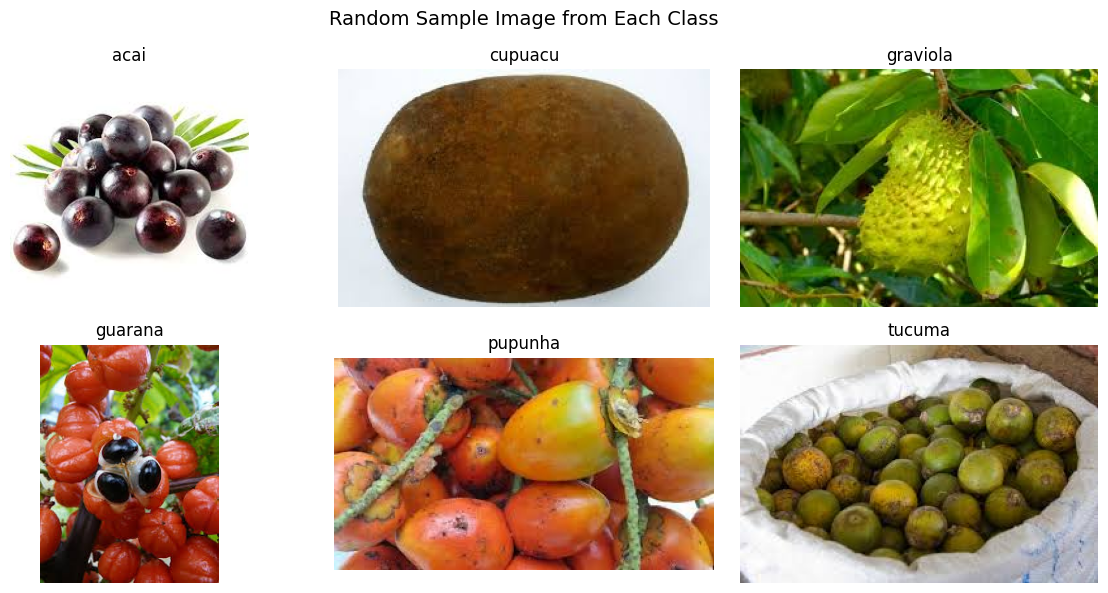

In [7]:
selected_images = []  # Store image paths
selected_labels = []  # Store corresponding class names

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if images:  # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Display in grid format
num_classes = len(selected_images)
cols = (num_classes + 1) // 2  # Determine columns
rows = 2  # Fixed rows for layout

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.suptitle("Random Sample Image from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 2.2: Data Generation and Pre-Processing

### Step 5: Generate Train and Validation Datasets

In [8]:
# Image configuration
image_size = (224, 224)  # Updated to 224x224 to match VGG16 input requirements
batch_size = 32

# Create train and validation datasets (80/20 split)
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

# Verify batch shape
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)  # (32, 224, 224, 3)
    print("Labels shape:", labels.shape)  # (32,)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


### Step 6: Visualize a Batch from the Training Dataset

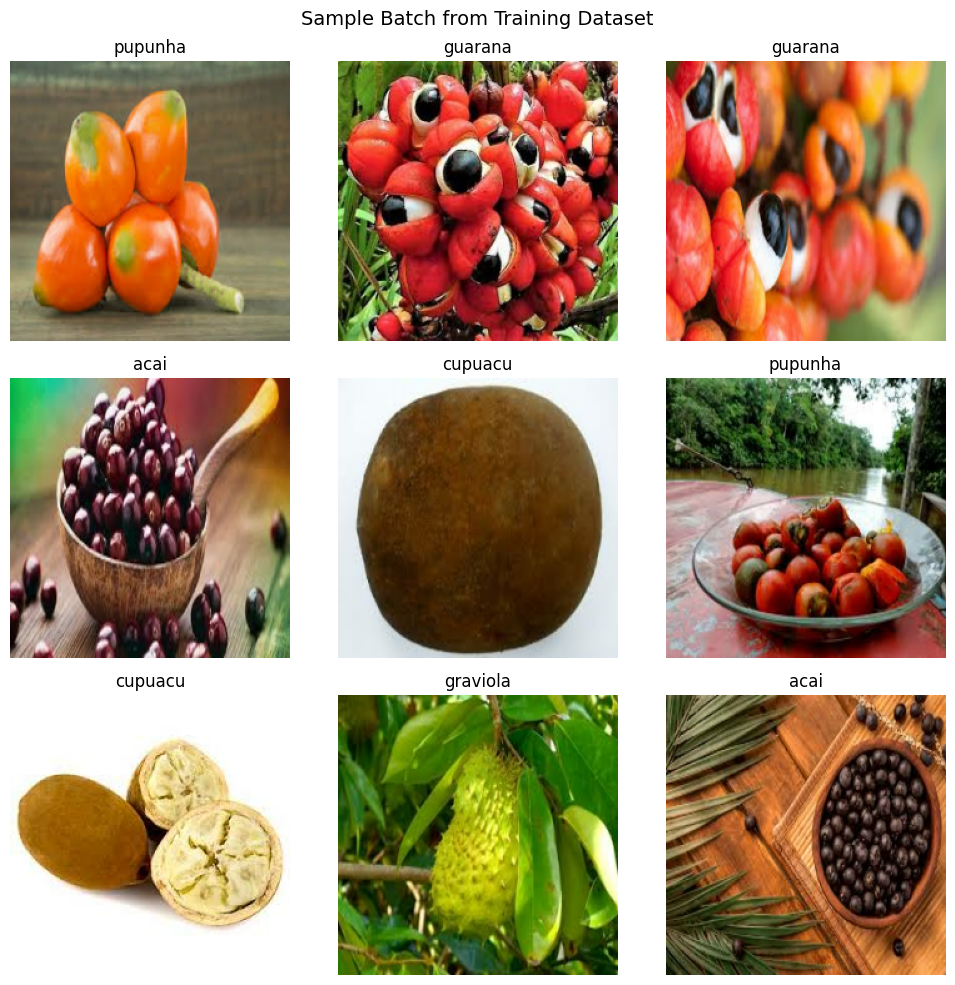

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Batch from Training Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### Step 7: Define Data Augmentation Layers (New Keras API)

In [10]:
# Using the new tf.keras.layers.Random* API (recommended)
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    """Apply all augmentation layers sequentially."""
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

print("Data augmentation layers defined:")
for layer in data_augmentation_layers:
    print(" -", layer.name)

Data augmentation layers defined:
 - random_flip
 - random_rotation
 - random_zoom
 - random_contrast


### Step 8: Visualize Augmented Images

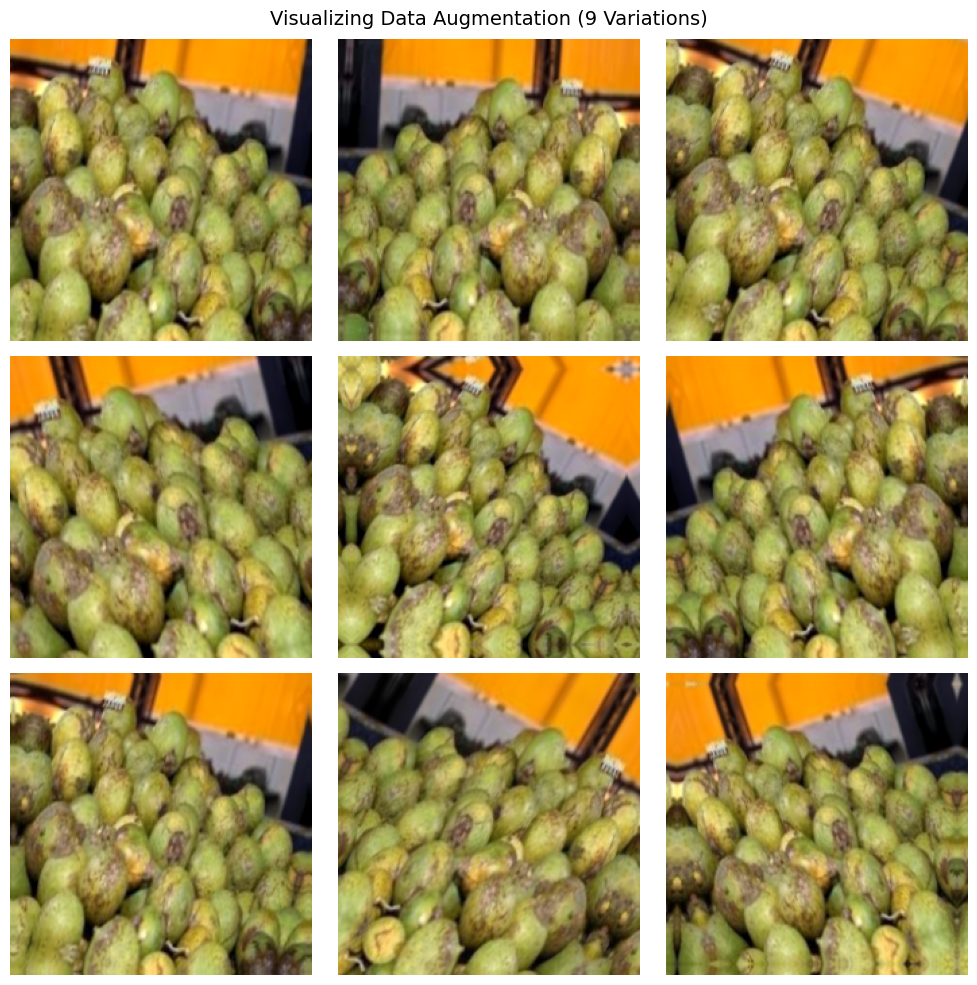

In [11]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Visualizing Data Augmentation (9 Variations)", fontsize=14)
plt.tight_layout()
plt.show()

### Step 9: Performance Optimization — Prefetching

In [12]:
# Use prefetching to improve training speed
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets cached and prefetched for optimal performance.")

Datasets cached and prefetched for optimal performance.


---
## Task 1: Improved CNN from Scratch with BatchNormalization and Dropout

### Step 10: Build the Enhanced CNN Model

In [13]:
num_classes = len(class_names)  # 6 for FruitsInAmazon
input_shape = (224, 224, 3)

# Build CNN model with BatchNormalization and Dropout
model_scratch = Sequential([
    # Data Augmentation + Rescaling (inside model = GPU accelerated)
    layers.Input(shape=input_shape),
    layers.Lambda(data_augmentation),
    layers.Rescaling(1./255),

    # --- Block 1 ---
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # --- Block 2 ---
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # --- Block 3 ---
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # --- Block 4 ---
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # --- Classifier Head ---
    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # --- Output Layer ---
    Dense(num_classes, activation='softmax')
])

# Compile
model_scratch.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,249,542 (100.13 MB)

 Trainable params: 26,246,790 (100.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

### Step 11: Train the Scratch CNN Model

In [14]:
# Define callbacks
callbacks_scratch = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        'best_scratch_model.keras', monitor='val_accuracy', save_best_only=True
    )
]

# Train
history_scratch = model_scratch.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks_scratch
)

print("\nTraining complete!")

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 6s/step - accuracy: 0.2083 - loss: 2.6297 - val_accuracy: 0.2222 - val_loss: 1.7300 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.1944 - loss: 2.1830 - val_accuracy: 0.2222 - val_loss: 1.7825 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.2222 - loss: 2.1475 - val_accuracy: 0.2222 - val_loss: 1.7664 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 8s/step - accuracy: 0.2917 - loss: 1.9528 - val_accuracy: 0.1667 - val_loss: 1.7896 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 8s/step - accuracy: 0.2222 - loss: 1.8927 - val_accuracy: 0.3333 - val_loss: 1.7711 - learning_rate: 5.0000e-04
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.3611 - loss: 1.7057 - val_accuracy: 0.2778 - val_loss: 1.7875 - learning_rate: 5.0000e-04

Training complete!


### Step 12: Evaluate Scratch CNN — Plot Training History

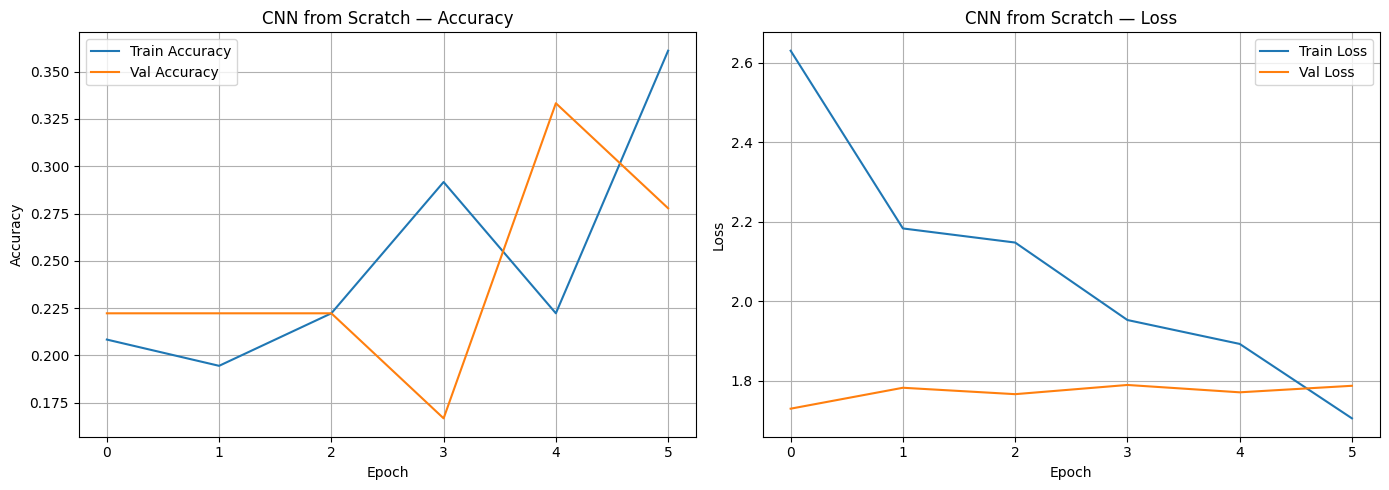

In [15]:
def plot_history(history, title="Training History"):
    """Plot accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_scratch, title="CNN from Scratch")

### Step 13: Evaluate Scratch CNN — Metrics and Classification Report

In [16]:
# Evaluate on validation set
val_loss_scratch, val_acc_scratch = model_scratch.evaluate(val_ds)
print(f"\n[Scratch CNN] Validation Loss    : {val_loss_scratch:.4f}")
print(f"[Scratch CNN] Validation Accuracy: {val_acc_scratch:.4f}")

# Generate Classification Report
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model_scratch.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\n--- Classification Report (Scratch CNN) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step - accuracy: 0.2222 - loss: 1.7300

[Scratch CNN] Validation Loss    : 1.7300
[Scratch CNN] Validation Accuracy: 0.2222

--- Classification Report (Scratch CNN) ---
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.22      1.00      0.36         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 14: Inference — Visualize Predictions (Scratch CNN)

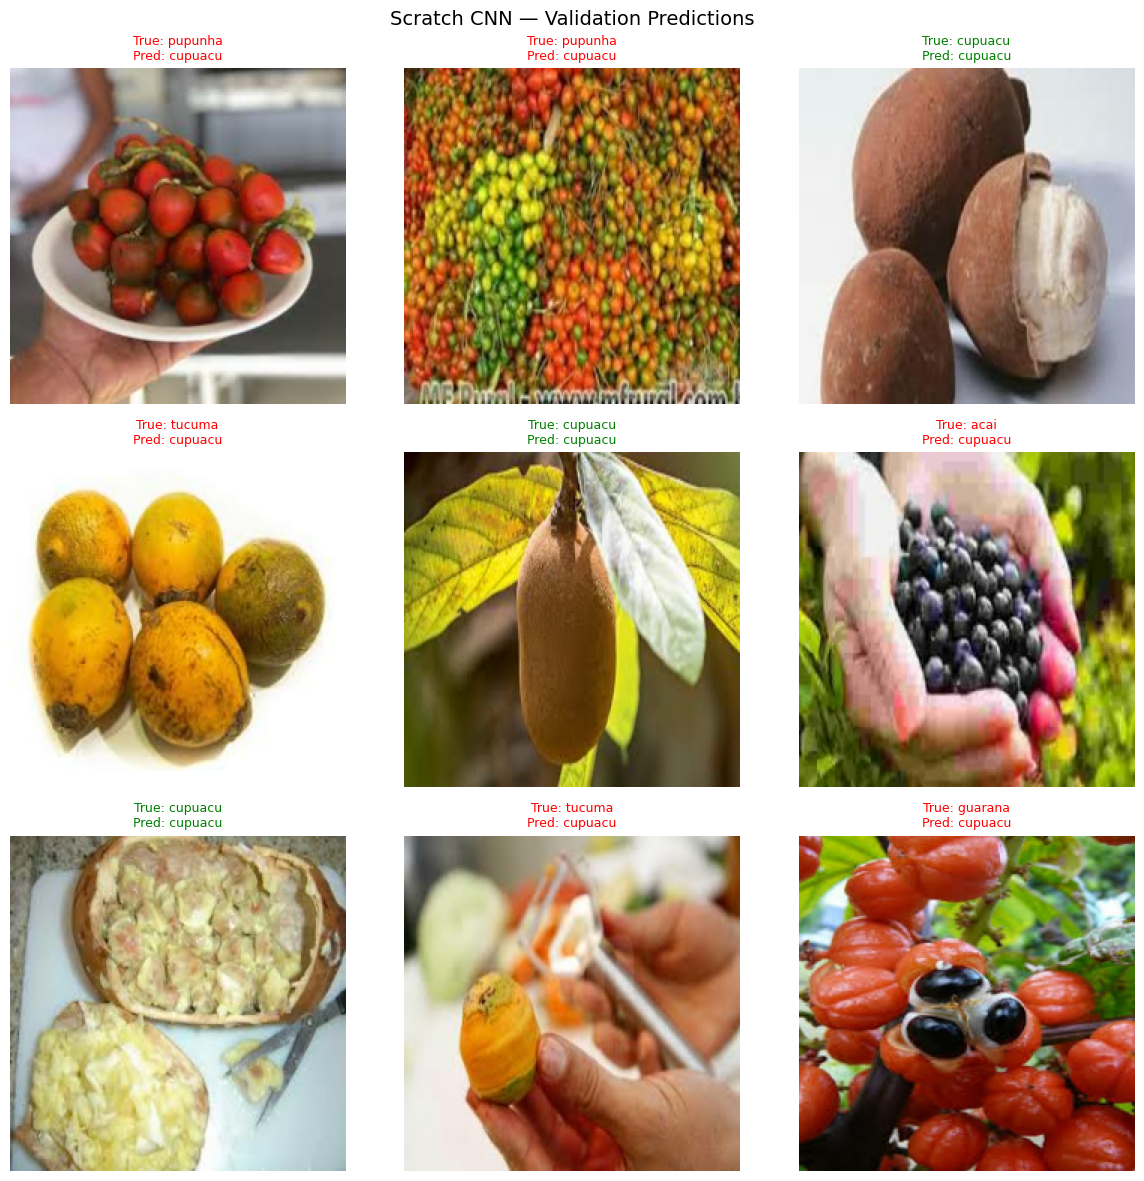

In [17]:
def visualize_predictions(model, dataset, class_names, num_images=9, title="Predictions"):
    """Visualize model predictions on a sample batch."""
    plt.figure(figsize=(12, 12))
    for images, labels in dataset.take(1):
        preds = model.predict(images[:num_images], verbose=0)
        pred_labels = np.argmax(preds, axis=1)

        for i in range(num_images):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(np.array(images[i]).astype("uint8"))
            true_label = class_names[int(labels[i])]
            pred_label = class_names[pred_labels[i]]
            color = "green" if true_label == pred_label else "red"
            ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
            plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_predictions(model_scratch, val_ds, class_names, title="Scratch CNN — Validation Predictions")

---
## Task 2: Transfer Learning with VGG16

### Step 15: Load Pre-trained VGG16 (without top layer)

In [18]:
# Load VGG16 pre-trained on ImageNet WITHOUT the classification head
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)  # VGG16 requires minimum 32x32, typically used at 224x224
)

print("VGG16 base model loaded.")
print(f"Number of layers in base model: {len(base_model.layers)}")
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
VGG16 base model loaded.
Number of layers in base model: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Step 16: Freeze All Base Model Layers

In [19]:
# Freeze all layers — preserve ImageNet learned features
for layer in base_model.layers:
    layer.trainable = False

# Verify frozen layers
trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
frozen_count    = sum(1 for layer in base_model.layers if not layer.trainable)
print(f"Trainable layers : {trainable_count}")
print(f"Frozen layers    : {frozen_count}")

Trainable layers : 0
Frozen layers    : 19


### Step 17: Add Custom Classification Head

In [20]:
# Build custom classification head on top of VGG16
x = base_model.output
x = GlobalAveragePooling2D()(x)          # Reduce (height, width) → 1D vector
x = Dense(1024, activation='relu')(x)    # Fully connected layer
x = Dropout(0.5)(x)                      # Regularization
x = Dense(512, activation='relu')(x)     # Additional dense layer
x = Dropout(0.3)(x)                      # Regularization
output = Dense(num_classes, activation='softmax')(x)  # Output: 6 classes

# Create the final model
model_vgg16 = Model(inputs=base_model.input, outputs=output)

# Compile with categorical crossentropy (note: one-hot labels would use categorical,
# but since we use integer labels from image_dataset_from_directory, use sparse)
model_vgg16.compile(
    optimizer=Adam(learning_rate=1e-4),  # Lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary — only custom head is trainable
model_vgg16.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,767,878 (60.15 MB)

 Trainable params: 1,053,190 (4.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 18: Prepare Dataset for VGG16 (Apply VGG16 Preprocessing)

In [21]:
from tensorflow.keras.applications.vgg16 import preprocess_input

# Re-create datasets with VGG16-specific preprocessing
train_ds_vgg, val_ds_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(224, 224),
    batch_size=batch_size,
)

# Apply VGG16 preprocessing (subtracts ImageNet mean, converts RGB→BGR)
train_ds_vgg = train_ds_vgg.map(
    lambda x, y: (preprocess_input(x), y)
).cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds_vgg = val_ds_vgg.map(
    lambda x, y: (preprocess_input(x), y)
).cache().prefetch(AUTOTUNE)

print("VGG16-preprocessed datasets ready.")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
VGG16-preprocessed datasets ready.


### Step 19: Train the VGG16 Transfer Learning Model

In [22]:
callbacks_vgg = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_vgg16_model.keras', monitor='val_accuracy', save_best_only=True
    )
]

history_vgg = model_vgg16.fit(
    train_ds_vgg,
    epochs=20,
    validation_data=val_ds_vgg,
    callbacks=callbacks_vgg
)

print("\nVGG16 Transfer Learning Training Complete!")

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 16s/step - accuracy: 0.1806 - loss: 9.2771 - val_accuracy: 0.1667 - val_loss: 3.4162 - learning_rate: 1.0000e-04
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 16s/step - accuracy: 0.3056 - loss: 5.7806 - val_accuracy: 0.3333 - val_loss: 2.5604 - learning_rate: 1.0000e-04
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 22s/step - accuracy: 0.2917 - loss: 4.3142 - val_accuracy: 0.2222 - val_loss: 2.7142 - learning_rate: 1.0000e-04
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.3333 - loss: 4.6819 - val_accuracy: 0.3889 - val_loss: 2.6881 - learning_rate: 1.0000e-04
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.3611 - loss: 4.1062 - val_accuracy: 0.4444 - val_loss: 2.5972 - learning_rate: 1.0000e-04
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 16s/step - accuracy: 0.5000 - loss: 2.6482 - val_accuracy: 0.4444 - val_loss: 2.4867 - learning_rate: 5.0000e-05
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 22s/step - accuracy: 0.3056 - loss: 3.4972

### Step 20: Evaluate VGG16 Transfer Learning Model

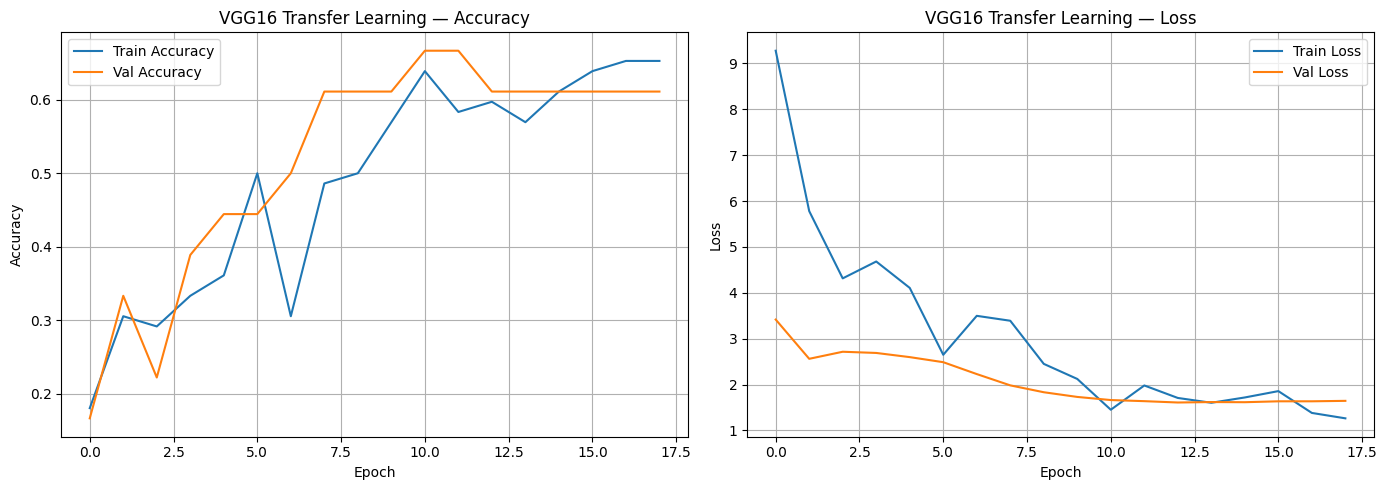

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.6111 - loss: 1.6078

[VGG16 Transfer] Validation Loss    : 1.6078
[VGG16 Transfer] Validation Accuracy: 0.6111

--- Classification Report (VGG16 Transfer Learning) ---
              precision    recall  f1-score   support

        acai       0.67      0.67      0.67         3
     cupuacu       0.80      1.00      0.89         4
    graviola       1.00      1.00      1.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.67      0.50      0.57         4
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.61        18
   macro avg       0.69      0.59      0.62        18
weighted avg       0.77      0.61      0.65        18



In [23]:
plot_history(history_vgg, title="VGG16 Transfer Learning")

# Evaluate on validation set
val_loss_vgg, val_acc_vgg = model_vgg16.evaluate(val_ds_vgg)
print(f"\n[VGG16 Transfer] Validation Loss    : {val_loss_vgg:.4f}")
print(f"[VGG16 Transfer] Validation Accuracy: {val_acc_vgg:.4f}")

# Generate Classification Report
y_true_vgg, y_pred_vgg = [], []

for images, labels in val_ds_vgg:
    preds = model_vgg16.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())

print("\n--- Classification Report (VGG16 Transfer Learning) ---")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))

### Step 21: Visualize VGG16 Predictions

Found 90 files belonging to 6 classes.
Using 18 files for validation.


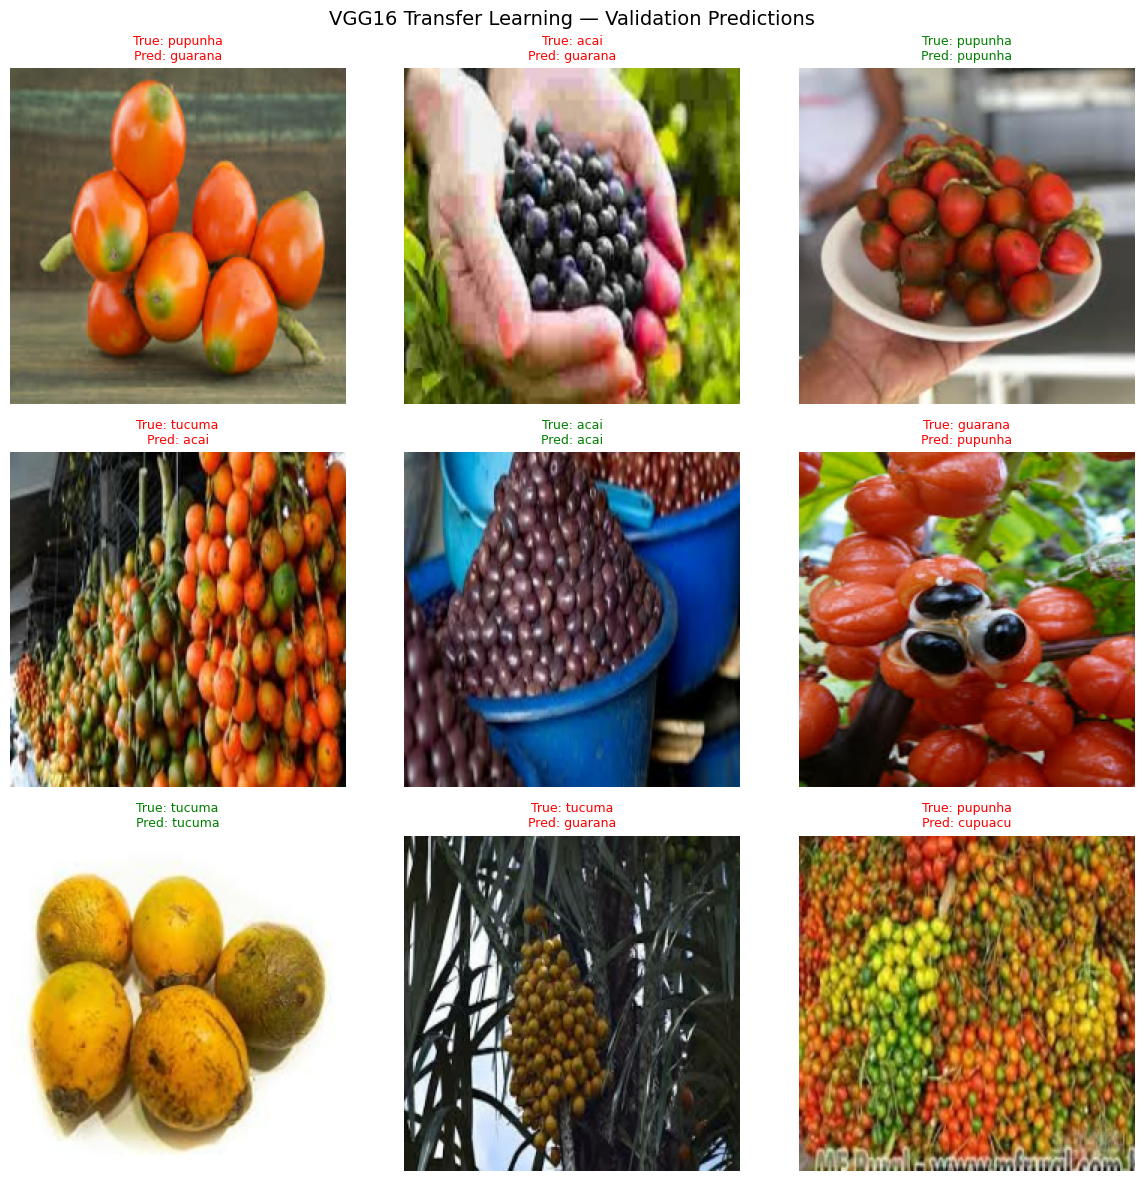

In [24]:
def visualize_predictions_vgg(model, dataset, class_names, num_images=9):
    """Visualize VGG16 model predictions (images shown as uint8 before preprocessing)."""
    # Re-load a raw batch for display
    raw_ds = keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=0.2,
        subset="validation",
        seed=1337,
        image_size=(224, 224),
        batch_size=num_images,
    )
    from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

    plt.figure(figsize=(12, 12))
    for raw_images, labels in raw_ds.take(1):
        preprocessed = vgg_preprocess(tf.cast(raw_images, tf.float32))
        preds = model.predict(preprocessed, verbose=0)
        pred_labels = np.argmax(preds, axis=1)

        for i in range(num_images):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(np.array(raw_images[i]).astype("uint8"))
            true_label = class_names[int(labels[i])]
            pred_label = class_names[pred_labels[i]]
            color = "green" if true_label == pred_label else "red"
            ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
            plt.axis("off")

    plt.suptitle("VGG16 Transfer Learning — Validation Predictions", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_predictions_vgg(model_vgg16, val_ds_vgg, class_names)

---
## Step 22: Comparison — Scratch CNN vs Transfer Learning

In [25]:
print("=" * 55)
print(f"{'Model':<30} {'Val Loss':>10} {'Val Acc':>10}")
print("=" * 55)
print(f"{'CNN from Scratch':<30} {val_loss_scratch:>10.4f} {val_acc_scratch:>10.4f}")
print(f"{'VGG16 Transfer Learning':<30} {val_loss_vgg:>10.4f} {val_acc_vgg:>10.4f}")
print("=" * 55)

improvement = (val_acc_vgg - val_acc_scratch) * 100
if improvement > 0:
    print(f"\nVGG16 improved accuracy by {improvement:.2f}% over training from scratch.")
else:
    print(f"\nScratch CNN performed {abs(improvement):.2f}% better than VGG16 in this run.")

Model                            Val Loss    Val Acc
CNN from Scratch                   1.7300     0.2222
VGG16 Transfer Learning            1.6078     0.6111

VGG16 improved accuracy by 38.89% over training from scratch.


---
## Step 23: Save Models

In [26]:
# Save both models in Keras format
model_scratch.save("cnn_scratch_final.keras")
model_vgg16.save("vgg16_transfer_final.keras")
print("Both models saved successfully.")

Both models saved successfully.


---
## Step 24: (Optional) Fine-tuning — Unfreeze Last VGG16 Block

In [27]:
# Optional: Fine-tune top convolutional block of VGG16 for better performance
# Unfreeze the last convolutional block (block5)
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True

# Recompile with a very low learning rate
model_vgg16.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_layers = [l.name for l in model_vgg16.layers if l.trainable]
print(f"Now training {len(trainable_layers)} layers including: {trainable_layers[-5:]}")

# Fine-tune
history_finetune = model_vgg16.fit(
    train_ds_vgg,
    epochs=10,
    validation_data=val_ds_vgg,
    callbacks=callbacks_vgg
)

# Evaluate after fine-tuning
ft_loss, ft_acc = model_vgg16.evaluate(val_ds_vgg)
print(f"\n[VGG16 Fine-tuned] Val Loss: {ft_loss:.4f} | Val Acc: {ft_acc:.4f}")

Now training 10 layers including: ['dense_4', 'dropout_7', 'dense_5', 'dropout_8', 'dense_6']
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 18s/step - accuracy: 0.6667 - loss: 1.7523 - val_accuracy: 0.6111 - val_loss: 1.5685 - learning_rate: 1.0000e-05
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 26s/step - accuracy: 0.6111 - loss: 1.4166 - val_accuracy: 0.6111 - val_loss: 1.5292 - learning_rate: 1.0000e-05
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 26s/step - accuracy: 0.6250 - loss: 1.5637 - val_accuracy: 0.6111 - val_loss: 1.4796 - learning_rate: 1.0000e-05
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 18s/step - accuracy: 0.7778 - loss: 0.8361 - val_accuracy: 0.6111 - val_loss: 1.4501 - learning_rate: 1.0000e-05
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 92s 24s/step - accuracy: 0.6389 - loss: 1.3393 - val_accuracy: 0.6111 - val_loss: 1.4226 - learning_rate: 1.0000e-05
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 18s/step - accuracy: 0.6806 - loss: 1.0340 - val_accuracy: 0.6111 - val_loss: 1.3998 - learning_rate:

---
## Summary & Observations

| Aspect | CNN from Scratch | VGG16 Transfer Learning |
|---|---|---|
| Training time | Longer | Shorter (frozen layers) |
| Data requirement | High | Low |
| Feature quality | Learned from scratch | Pre-learned on ImageNet |
| Overfitting risk | Higher | Lower (with dropout) |
| Typical accuracy | Moderate | Higher |

**Key Takeaways:**
1. **BatchNormalization** stabilizes training and accelerates convergence by normalizing layer inputs.
2. **Dropout** reduces overfitting by randomly disabling neurons during training.
3. **Data Augmentation** improves generalization by exposing the model to varied transformations.
4. **Transfer Learning** with VGG16 typically outperforms training from scratch — especially with small datasets — because pre-trained features from ImageNet are highly transferable to other image classification tasks.
5. The **new `tf.keras.layers.Random*` API** is preferred over the old `ImageDataGenerator` as augmentation runs on the GPU during `model.fit()`.